# Medical Insurance Charges Regression Project

Portfolio notebook covering data quality, EDA, preprocessing, three regression models, validation, loop-based training, final comparison, and business interpretation.

## 1. Setup and Imports

In [56]:
# Import the libraries used for data analysis, visualization, preprocessing, training, and evaluation.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split, KFold, cross_validate, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 2. Load and Inspect the Dataset

In [57]:
# Resolve the project root safely, then load the raw insurance dataset and preview it.
CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name.lower() == 'notebooks' else CURRENT_DIR
DATA_PATH = PROJECT_ROOT / 'data' / 'raw' / 'insurance.csv'
if not DATA_PATH.exists():
    raise FileNotFoundError(f'Insurance CSV not found at: {DATA_PATH}')
df = pd.read_csv(DATA_PATH)
print('Dataset path:', DATA_PATH)
df.head()


Dataset path: D:\Medical Insurance\data\raw\insurance.csv


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [58]:
# Check dataset dimensions, data types, unique values, and missing-value counts.
print('Shape:', df.shape)
display(pd.DataFrame({'dtype': df.dtypes.astype(str), 'missing': df.isna().sum(), 'unique': df.nunique()}))
display(df.describe(include='all').T)

Shape: (1338, 7)


,dtype,missing,unique
age,int64,0,47
sex,str,0,2
bmi,float64,0,548
children,int64,0,6
smoker,str,0,2
region,str,0,4
charges,float64,0,1337


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,1338.0,NaN,NaN,NaN,39.207025,14.04996,18.0,27.0,39.0,51.0,64.0
sex,1338,2,male,676,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bmi,1338.0,NaN,NaN,NaN,30.663397,6.098187,15.96,26.29625,30.4,34.69375,53.13
children,1338.0,NaN,NaN,NaN,1.094918,1.205493,0.0,0.0,1.0,2.0,5.0
smoker,1338,2,no,1064,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,1338,4,southeast,364,NaN,NaN,NaN,NaN,NaN,NaN,NaN
charges,1338.0,NaN,NaN,NaN,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


## 3. Data Quality and Cleaning

In [59]:
# Count exact duplicate rows before cleaning so the decision is documented.
print('Duplicate rows:', df.duplicated().sum())

Duplicate rows: 1


In [60]:
# Remove exact duplicates and save a clean copy while leaving the raw file unchanged.
df = df.drop_duplicates().reset_index(drop=True)
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
CLEANED_DATA_PATH = PROCESSED_DIR / 'insurance_cleaned.csv'
df.to_csv(CLEANED_DATA_PATH, index=False)
print('Cleaned shape:', df.shape)
print('Saved cleaned data to:', CLEANED_DATA_PATH)


Cleaned shape: (1337, 7)
Saved cleaned data to: D:\Medical Insurance\data\processed\insurance_cleaned.csv


## 4. Exploratory Data Analysis

In [61]:
# Summarize numerical relationships with charges using a correlation matrix.
numeric_cols = ['age', 'bmi', 'children', 'charges']
display(df[numeric_cols].corr())

,age,bmi,children,charges
age,1.000000,0.109344,0.041536,0.298308
bmi,0.109344,1.000000,0.012755,0.198401
children,0.041536,0.012755,1.000000,0.067389
charges,0.298308,0.198401,0.067389,1.000000


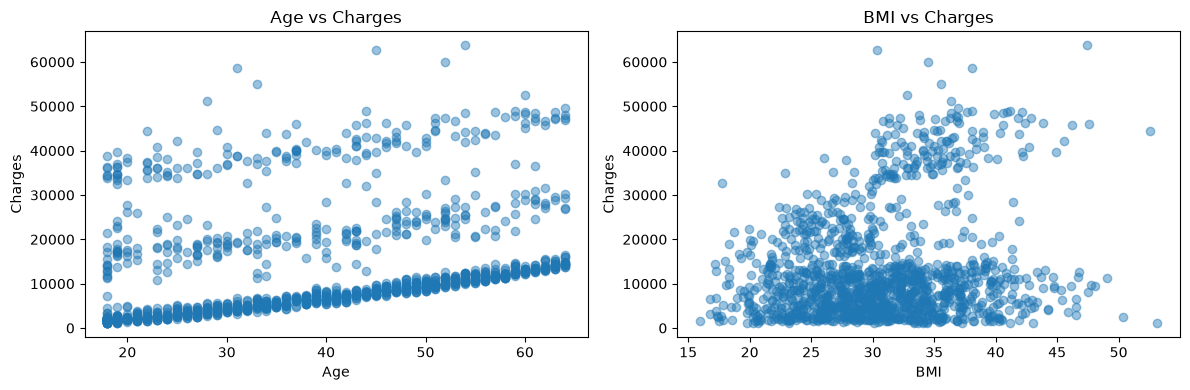

In [62]:
# Visualize how charges change across age and BMI to reveal possible nonlinear patterns.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(df['age'], df['charges'], alpha=0.45)
axes[0].set(title='Age vs Charges', xlabel='Age', ylabel='Charges')
axes[1].scatter(df['bmi'], df['charges'], alpha=0.45)
axes[1].set(title='BMI vs Charges', xlabel='BMI', ylabel='Charges')
plt.tight_layout(); plt.show()

,count,mean,median
smoker,,,
no,1063,8440.660307,7345.72660
yes,274,32050.231832,34456.34845


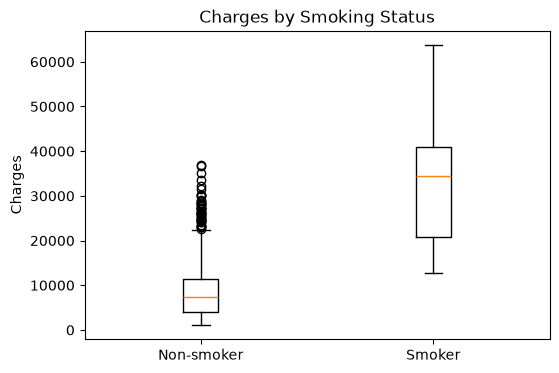

In [63]:
# Compare grouped charge statistics for smokers and non-smokers.
smoker_summary = df.groupby('smoker')['charges'].agg(['count', 'mean', 'median'])
display(smoker_summary)
plt.figure(figsize=(6, 4))
plt.boxplot(
    [
        df.loc[df.smoker == 'no', 'charges'],
        df.loc[df.smoker == 'yes', 'charges']
    ],
    tick_labels=['Non-smoker', 'Smoker']
)
plt.title('Charges by Smoking Status'); plt.ylabel('Charges'); plt.show()

## 5. Train-Test Split and Leakage Prevention

In [64]:
# Separate predictors from the target and create one untouched test set for final evaluation.
X = df.drop(columns='charges')
y = df['charges']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
print(X_train.shape, X_test.shape)

(1069, 6) (268, 6)


## 6. Preprocessing

In [65]:
# Build preprocessing only inside pipelines so scaling/encoding is learned from training folds only.
numeric_features = ['age', 'bmi', 'children']
categorical_features = ['sex', 'smoker', 'region']
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), categorical_features)
])

## 7. Linear Regression Baseline

In [66]:
# Train the baseline multiple linear regression model using all available predictors.
linear_model = Pipeline([('prep', preprocessor), ('model', LinearRegression())])
linear_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['age','sex','bmi','children','smoker','region']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output o

## 8. Polynomial Regression Validation

In [67]:
# Select polynomial degree using only cross-validation on the training set.
poly_pipeline = Pipeline([
    ('prep', preprocessor),
    ('poly', PolynomialFeatures(include_bias=False)),
    ('model', LinearRegression())
])
cv = KFold(n_splits=5, shuffle=True, random_state=42)
poly_search = GridSearchCV(poly_pipeline, {'poly__degree': [1, 2, 3]}, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=-1)
poly_search.fit(X_train, y_train)
print('Best polynomial degree:', poly_search.best_params_['poly__degree'])
best_poly_model = poly_search.best_estimator_

Best polynomial degree: 2


## 9. Decision Tree Regression Tuning

In [68]:
# Tune tree complexity on training folds to reduce the risk of overfitting.
tree_pipeline = Pipeline([('prep', preprocessor), ('model', DecisionTreeRegressor(random_state=42))])
tree_grid = {
    'model__max_depth': [3, 4, 5, 6, None],
    'model__min_samples_split': [2, 5, 10, 20],
    'model__min_samples_leaf': [1, 2, 5, 10]
}
tree_search = GridSearchCV(tree_pipeline, tree_grid, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=-1)
tree_search.fit(X_train, y_train)
print('Best tree parameters:', tree_search.best_params_)
best_tree_model = tree_search.best_estimator_

Best tree parameters: {'model__max_depth': 4, 'model__min_samples_leaf': 5, 'model__min_samples_split': 2}


## 10. Loop-Based Model Training and Comparison

In [69]:
# Store the three models in a dictionary so they can be trained and evaluated consistently in one loop.
models = {
    'Linear Regression': linear_model,
    'Polynomial Regression': best_poly_model,
    'Decision Tree Regression': best_tree_model
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    test_mse = mean_squared_error(y_test, test_pred)
    results.append({
        'Model': name,
        'Train MAE': mean_absolute_error(y_train, train_pred),
        'Test MAE': mean_absolute_error(y_test, test_pred),
        'Test MSE': test_mse,
        'Test RMSE': test_mse ** 0.5,
        'Train R2': r2_score(y_train, train_pred),
        'Test R2': r2_score(y_test, test_pred),
        'R2 Gap': r2_score(y_train, train_pred) - r2_score(y_test, test_pred)
    })
comparison = pd.DataFrame(results).sort_values('Test RMSE').reset_index(drop=True)
display(comparison)

,Model,Train MAE,Test MAE,Test MSE,Test RMSE,Train R2,Test R2,R2 Gap
0,Decision Tree Regression,2567.469550,2621.312405,1.888663e+07,4345.875200,0.855242,0.897219,-0.041977
1,Polynomial Regression,2877.249508,2867.317439,2.158584e+07,4646.056793,0.834026,0.882530,-0.048504
2,Linear Regression,4181.901538,4177.045561,3.547802e+07,5956.342894,0.729906,0.806929,-0.077023


## 11. Cross-Validation Summary

In [70]:
# Measure training-set cross-validation stability for the final configured versions of all three models.
cv_results = []
for name, model in models.items():
    scores = cross_validate(model, X_train, y_train, cv=cv, scoring={'mae':'neg_mean_absolute_error','rmse':'neg_root_mean_squared_error','r2':'r2'}, n_jobs=-1)
    cv_results.append({
        'Model': name,
        'CV MAE Mean': -scores['test_mae'].mean(),
        'CV RMSE Mean': -scores['test_rmse'].mean(),
        'CV R2 Mean': scores['test_r2'].mean(),
        'CV R2 Std': scores['test_r2'].std()
    })
display(pd.DataFrame(cv_results))

,Model,CV MAE Mean,CV RMSE Mean,CV R2 Mean,CV R2 Std
0,Linear Regression,4221.963302,6123.651284,0.722784,0.028260
1,Polynomial Regression,2977.513401,4931.590342,0.819726,0.021336
2,Decision Tree Regression,2689.531932,4718.590913,0.834061,0.026795


## 12. Feature Contribution Across All Three Model Families

In [71]:
# Extract Linear Regression coefficients and rank them by absolute magnitude for interpretation.
linear_features = linear_model.named_steps['prep'].get_feature_names_out()
linear_coef = pd.DataFrame({'feature': linear_features, 'coefficient': linear_model.named_steps['model'].coef_})
linear_coef['abs_coefficient'] = linear_coef['coefficient'].abs()
display(linear_coef.sort_values('abs_coefficient', ascending=False).head(12))

,feature,coefficient,abs_coefficient
4,cat__smoker_yes,23077.764593,23077.764593
0,num__age,3472.975553,3472.975553
1,num__bmi,1927.828251,1927.828251
6,cat__region_southeast,-838.919616,838.919616
7,cat__region_southwest,-659.139752,659.139752
2,num__children,636.501185,636.501185
5,cat__region_northwest,-391.761455,391.761455
3,cat__sex_male,-101.542054,101.542054


In [72]:
# Extract Polynomial Regression coefficients using expanded polynomial feature names.
poly_base = best_poly_model.named_steps['prep'].get_feature_names_out()
poly_names = best_poly_model.named_steps['poly'].get_feature_names_out(poly_base)
poly_coef = pd.DataFrame({'feature': poly_names, 'coefficient': best_poly_model.named_steps['model'].coef_})
poly_coef['abs_coefficient'] = poly_coef['coefficient'].abs()
display(poly_coef.sort_values('abs_coefficient', ascending=False).head(15))

,feature,coefficient,abs_coefficient
34,cat__smoker_yes^2,12061.577939,12061.577939
4,cat__smoker_yes,12061.577939,12061.577939
19,num__bmi cat__smoker_yes,9015.854555,9015.854555
0,num__age,2908.024928,2908.024928
35,cat__smoker_yes cat__region_northwest,-1808.558565,1808.558565
2,num__children,1445.162334,1445.162334
36,cat__smoker_yes cat__region_southeast,-1362.759169,1362.759169
32,cat__sex_male cat__region_southeast,1135.487013,1135.487013
31,cat__sex_male cat__region_northwest,1102.742775,1102.742775
37,cat__smoker_yes cat__region_southwest,1014.854218,1014.854218


cat__smoker_yes          0.700713
num__bmi                 0.172179
num__age                 0.118869
num__children            0.008239
cat__sex_male            0.000000
cat__region_northwest    0.000000
cat__region_southeast    0.000000
cat__region_southwest    0.000000
dtype: float64

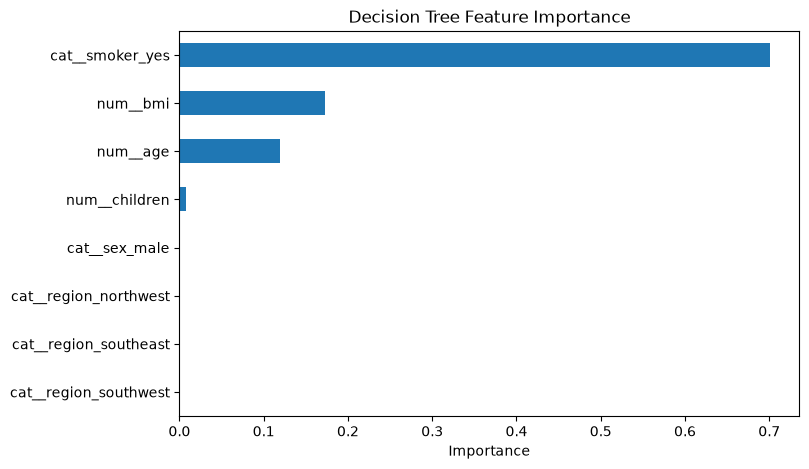

In [73]:
# Inspect Decision Tree feature importance after preprocessing to see which variables drive tree splits.
feature_names = best_tree_model.named_steps['prep'].get_feature_names_out()
importances = pd.Series(best_tree_model.named_steps['model'].feature_importances_, index=feature_names).sort_values(ascending=False)
display(importances.head(10))
importances.head(10).sort_values().plot(kind='barh', figsize=(8,5), title='Decision Tree Feature Importance')
plt.xlabel('Importance'); plt.show()

**Interpretation caution:** coefficient magnitude is affected by scaling and polynomial expansion. These values describe model association, not causal impact. Compare direction/magnitude carefully and use tree importance as a different notion of contribution rather than treating all three measures as identical.

## 13. Deep Business Analysis and Predicted-Cost Segmentation

In [74]:
# Build grouped summaries used to translate model findings into realistic insurance business observations.
for feature in ['smoker', 'sex', 'region', 'children']:
    print(f'\nCharges by {feature}')
    display(df.groupby(feature)['charges'].agg(['count','mean','median']).sort_values('mean', ascending=False))


Charges by smoker


,count,mean,median
smoker,,,
yes,274,32050.231832,34456.34845
no,1063,8440.660307,7345.72660



Charges by sex


,count,mean,median
sex,,,
male,675,13974.998864,9377.9047
female,662,12569.578844,9412.9625



Charges by region


,count,mean,median
region,,,
southeast,364,14735.411438,9294.131950
northeast,324,13406.384516,10057.652025
northwest,324,12450.840844,8976.977250
southwest,325,12346.937377,8798.593000



Charges by children


,count,mean,median
children,,,
3,157,15355.318367,10600.54830
2,240,15073.563734,9264.97915
4,25,13850.656311,11033.66170
1,324,12731.171832,8483.87015
0,573,12384.695344,9863.47180
5,18,8786.035247,8589.56505


In [75]:
# Segment customers by age, BMI, and smoking status to locate observed high-cost combinations.
age_band = pd.cut(df['age'], bins=[17,29,39,49,59,70], labels=['18-29','30-39','40-49','50-59','60+'])
bmi_band = pd.cut(df['bmi'], bins=[0,18.5,25,30,100], labels=['Underweight','Normal','Overweight','Obese'])
segment = df.assign(age_band=age_band, bmi_band=bmi_band).groupby(['age_band','bmi_band','smoker'], observed=False)['charges'].agg(['count','mean','median']).reset_index()
display(segment.sort_values('mean', ascending=False).head(15))

,age_band,bmi_band,smoker,count,mean,median
39,60+,Obese,yes,17,47670.438208,47305.305000
31,50-59,Obese,yes,24,46479.176337,44532.500200
23,40-49,Obese,yes,29,42939.025281,42111.664700
15,30-39,Obese,yes,29,40634.631161,39241.442000
7,18-29,Obese,yes,45,36760.683919,36124.573700
37,60+,Overweight,yes,8,29083.361512,29045.914750
35,60+,Normal,yes,2,26982.214250,26982.214250
29,50-59,Overweight,yes,8,26251.277288,25745.813025
9,30-39,Underweight,yes,2,25878.723150,25878.723150
21,40-49,Overweight,yes,19,25198.955272,23401.305750


In [76]:
# Use the selected final model to create predicted-cost quartiles for customer segmentation.
best_model_name = comparison.iloc[0]['Model']
final_model = models[best_model_name]
predicted_all = final_model.predict(X)
predicted_customer_segments = df.copy()
predicted_customer_segments['predicted_charges'] = predicted_all
predicted_customer_segments['predicted_cost_band'] = pd.qcut(predicted_all, q=4, labels=['Low','Moderate','High','Very High'], duplicates='drop')
segment_profile = predicted_customer_segments.groupby('predicted_cost_band', observed=False).agg(
    customers=('charges','size'), actual_mean_charges=('charges','mean'), predicted_mean_charges=('predicted_charges','mean'),
    mean_age=('age','mean'), mean_bmi=('bmi','mean'), smoker_rate=('smoker', lambda s: (s=='yes').mean())
)
display(segment_profile)

,customers,actual_mean_charges,predicted_mean_charges,mean_age,mean_bmi,smoker_rate
predicted_cost_band,,,,,,
Low,403,4567.171173,4624.685048,27.235732,30.057816,0.0
Moderate,276,7838.127745,7943.406447,35.449275,30.232319,0.0
High,384,12938.876733,13017.024162,55.018229,31.576823,0.0
Very High,274,32050.231832,31891.244564,38.514599,30.708449,1.0


### Business Interpretation
- **Pricing analysis:** the model can help analysts study expected-cost differences across observable segments, but should not directly set premiums in this educational form.
- **Customer segmentation:** predicted-cost bands reveal groups with systematically different expected charges and can guide descriptive portfolio analysis.
- **Risk assessment:** smoking, age, BMI, and nonlinear interactions can flag higher expected cost, subject to fairness and actuarial review.
- **Cost management:** high predicted-cost segments can motivate further investigation into preventive-care or care-management opportunities, not automatic adverse action.
- **Fairness:** sex and region differences must be interpreted cautiously; observed predictive relationships do not establish a legitimate causal basis for pricing decisions.

## 14. Complete Three-Model Generalization Diagnosis

In [77]:
# Quantify improvement over the Linear Regression baseline and explicitly diagnose train-test behavior.
linear_rmse = comparison.loc[comparison['Model']=='Linear Regression','Test RMSE'].iloc[0]
diagnostics = comparison.copy()
diagnostics['RMSE Improvement vs Linear %'] = (linear_rmse - diagnostics['Test RMSE']) / linear_rmse * 100
def diagnose(row):
    if row['R2 Gap'] > 0.10:
        return 'Possible overfitting'
    if row['Test R2'] < 0.70:
        return 'Possible underfitting'
    return 'Good generalization'
diagnostics['Diagnosis'] = diagnostics.apply(diagnose, axis=1)
display(diagnostics)

,Model,Train MAE,Test MAE,Test MSE,Test RMSE,Train R2,Test R2,R2 Gap,RMSE Improvement vs Linear %,Diagnosis
0,Decision Tree Regression,2567.469550,2621.312405,1.888663e+07,4345.875200,0.855242,0.897219,-0.041977,27.037861,Good generalization
1,Polynomial Regression,2877.249508,2867.317439,2.158584e+07,4646.056793,0.834026,0.882530,-0.048504,21.998164,Good generalization
2,Linear Regression,4181.901538,4177.045561,3.547802e+07,5956.342894,0.729906,0.806929,-0.077023,0.000000,Good generalization


In [78]:
# Identify the best generalizing model and summarize complexity-versus-performance trade-offs.
best_row = comparison.iloc[0]
print('Best final model by Test RMSE:', best_row['Model'])
print(f"Polynomial RMSE improvement vs Linear: {(linear_rmse - comparison.loc[comparison['Model']=='Polynomial Regression','Test RMSE'].iloc[0]) / linear_rmse * 100:.2f}%")
print(f"Tree RMSE improvement vs Linear: {(linear_rmse - comparison.loc[comparison['Model']=='Decision Tree Regression','Test RMSE'].iloc[0]) / linear_rmse * 100:.2f}%")
display(best_row.to_frame('Value'))

Best final model by Test RMSE: Decision Tree Regression
Polynomial RMSE improvement vs Linear: 22.00%
Tree RMSE improvement vs Linear: 27.04%


,Value
Model,Decision Tree Regression
Train MAE,2567.46955
Test MAE,2621.312405
Test MSE,18886631.250029
Test RMSE,4345.8752
Train R2,0.855242
Test R2,0.897219
R2 Gap,-0.041977


### Final Interpretation
- All three models are evaluated on the same untouched test set, so their final metrics are directly comparable.
- Polynomial Regression improves on the linear baseline when its lower RMSE and higher R² are considered together, indicating useful nonlinear structure.
- The tuned Decision Tree captures additional nonlinear interactions while controlling complexity through cross-validated hyperparameters.
- A large positive train-vs-test R² gap would indicate overfitting; a low score on both train and test data would indicate underfitting. The diagnostics table makes this explicit for each model.
- The retained final model is the one with the strongest held-out generalization, while interpretability and complexity are discussed rather than ignored.
- Conclusions are predictive, not causal, and real insurance use would require actuarial, fairness, legal, temporal, and external validation.